# Лабораторна робота №2
## Пошук асоціативних правил


### Мета:

Ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.


#### 1. Завантаження та підготовка даних
1. Викачати архів ml-latest-small.zip і розпакувати.
2. Завантажити таблиці ratings.csv і movies.csv за допомогою pandas.


In [54]:
import pandas as pd
import numpy as np

ratings = pd.read_csv("DM_lab/ratings.csv")
movies = pd.read_csv("DM_lab/movies.csv")

ratings.head()
movies.head()

print("Форма таблиці ratings:", ratings.shape)
print("Форма таблиці movies:", movies.shape)

Форма таблиці ratings: (100836, 4)
Форма таблиці movies: (9742, 3)


3. Виконати об’єднання таблиць за полем movieId.

In [55]:
merged_data = pd.merge(ratings, movies, on='movieId')
print("Форма об'єднаної таблиці:", merged_data.shape)

Форма об'єднаної таблиці: (100836, 6)


4. Для подальшого аналізу вибрати лише користувацькі оцінки rating ≥ 4.0, вважаючи, що це “фільми що сподобались користувачам”.


In [56]:
merged_data = merged_data[merged_data['rating'] >= 4.0]
print("Форма таблиці після фільтрації:", merged_data.shape)

Форма таблиці після фільтрації: (48580, 6)


5. Вивести розміри таблиць та кількість унікальних користувачів і фільмів.

In [57]:
unique_users = merged_data["userId"].nunique()
unique_movies = merged_data["title"].nunique()

print("Кількість унікальних користувачів:", unique_users)
print("Кількість унікальних фільмів:", unique_movies)


Кількість унікальних користувачів: 609
Кількість унікальних фільмів: 6297


#### 2. Перетворення даних у транзакційний формат

1. Створити матрицю (або DataFrame) у форматі: рядки — користувачі (userId), стовпці — фільми (title), значення — 1, якщо користувач поставив оцінку ≥ 4.0, і 0 інакше.

In [58]:
transaction_matrix = merged_data.pivot_table(
    index='userId',
    columns='title',
    values='rating',
    aggfunc='max',
    fill_value=0
)
transaction_matrix = (transaction_matrix > 0)

2. Вивести кілька перших рядків матриці для перевірки.

In [59]:
print("Форма транзакційної матриці:", transaction_matrix.shape)

Форма транзакційної матриці: (609, 6297)


In [60]:
print("Перші 5 рядків транзакційної матриці:")
display(transaction_matrix.head())

Перші 5 рядків транзакційної матриці:


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### 3. Пошук частих наборів фільмів
1. Використати алгоритм Apriori для пошуку частих наборів елементів.
2. Вивести кількість знайдених частих наборів при різних порогах 


In [61]:
from mlxtend.frequent_patterns import apriori

supports = [0.05, 0.1, 0.3]

for s in supports:
    frequent = apriori(transaction_matrix, min_support=s, use_colnames=True)
    print(f"min_support = {s} → кількість наборів: {len(frequent)}")

min_support = 0.05 → кількість наборів: 33189
min_support = 0.1 → кількість наборів: 863
min_support = 0.3 → кількість наборів: 6


3. Відсортувати результати за значенням support

In [62]:
min_support = 0.1
frequent_itemsets = apriori(
    transaction_matrix,
    min_support,
    use_colnames=True
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_sorted = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

In [63]:
top10 = frequent_sorted.head(10)
print("Топ-10 найпопулярніших наборів:")
display(top10)

Топ-10 найпопулярніших наборів:


,support,itemsets,length
93,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
40,0.408867,frozenset({Forrest Gump (1994)}),1
83,0.400657,frozenset({Pulp Fiction (1994)}),1
96,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
68,0.364532,"frozenset({Matrix, The (1999)})",1
103,0.330049,frozenset({Star Wars: Episode IV - A New Hope (1977)}),1
38,0.293924,frozenset({Fight Club (1999)}),1
90,0.287356,frozenset({Schindler's List (1993)}),1
279,0.275862,"frozenset({Forrest Gump (1994), Shawshank Redemption, The (1994)})",2
104,0.275862,frozenset({Star Wars: Episode V - The Empire Strikes Back (1980)}),1


4. Вивести топ-10 найпопулярніших комбінацій фільмів.


In [64]:
top_combinations = frequent_sorted[
    frequent_sorted['length'] >= 2
].head(10)

print("Топ-10 комбінацій фільмів:")
pd.set_option('display.max_colwidth', None)
display(top_combinations)

Топ-10 комбінацій фільмів:


,support,itemsets,length
279,0.275862,"frozenset({Forrest Gump (1994), Shawshank Redemption, The (1994)})",2
448,0.259442,"frozenset({Shawshank Redemption, The (1994), Pulp Fiction (1994)})",2
449,0.249589,"frozenset({Silence of the Lambs, The (1991), Pulp Fiction (1994)})",2
515,0.236453,"frozenset({Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode IV - A New Hope (1977)})",2
495,0.229885,"frozenset({Silence of the Lambs, The (1991), Shawshank Redemption, The (1994)})",2
274,0.223317,"frozenset({Forrest Gump (1994), Pulp Fiction (1994)})",2
484,0.211823,"frozenset({Schindler's List (1993), Shawshank Redemption, The (1994)})",2
281,0.210181,"frozenset({Silence of the Lambs, The (1991), Forrest Gump (1994)})",2
411,0.208539,"frozenset({Matrix, The (1999), Pulp Fiction (1994)})",2
516,0.206897,"frozenset({Star Wars: Episode VI - Return of the Jedi (1983), Star Wars: Episode IV - A New Hope (1977)})",2


5. Інтерпретувати, які фільми часто зустрічаються разом у вподобаннях користувачів.

Користувачі часто одночасно оцінюють популярні та культові фільми, особливо стрічки 90-х років і відомі франшизи. Найчастіше разом зустрічаються такі фільми, як Forrest Gump (1994) і The Shawshank Redemption (1994) (support = 27.6%). Подібна тенденція спостерігається і для пар The Shawshank Redemption (1994) та Pulp Fiction (1994), а також The Silence of the Lambs (1991) і Pulp Fiction (1994). Пари зі Star Wars (наприклад, епізоди IV і V або IV і VI) демонструють, що користувачі, які переглядають один фільм франшизи, зазвичай дивляться й інші частини. Користувачі часто оцінюють разом популярні та культові фільми, особливо стрічки однієї франшизи або схожих жанрів.

#### 4. Побудова асоціативних правил
1. Побудувати асоціативні правила.


In [65]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)
print("Кількість правил:", len(rules))
display(rules.head())

Кількість правил: 1112


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Aladdin (1992)}),frozenset({Forrest Gump (1994)}),0.185550,0.408867,0.119869,0.646018,1.580019,1.0,0.044003,1.669951,0.450729,0.252595,0.401180,0.469595
1,"frozenset({Lion King, The (1994)})",frozenset({Aladdin (1992)}),0.188834,0.185550,0.114943,0.608696,3.280492,1.0,0.079904,2.081372,0.856998,0.443038,0.519548,0.614082
2,frozenset({Aladdin (1992)}),"frozenset({Lion King, The (1994)})",0.185550,0.188834,0.114943,0.619469,3.280492,1.0,0.079904,2.131668,0.853543,0.443038,0.530884,0.614082
3,frozenset({Aliens (1986)}),frozenset({Alien (1979)}),0.139573,0.180624,0.106732,0.764706,4.233690,1.0,0.081522,3.482348,0.887698,0.500000,0.712837,0.677807
4,frozenset({Alien (1979)}),"frozenset({Matrix, The (1999)})",0.180624,0.364532,0.124795,0.690909,1.895332,1.0,0.058952,2.055926,0.576521,0.296875,0.513601,0.516626


2. Додати обчислення метрик support, confidence, lift.
3. Відсортувати та вивести топ-10 правил за lift.


In [66]:
rules_display = rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].copy()
rules_display['rule'] = rules_display['antecedents'].astype(str) + ' → ' + rules_display['consequents'].astype(str)

In [67]:
print("Топ-10 правил за lift:")
top_rules_lift = rules_display.sort_values('lift', ascending=False).head(10)

display(top_rules_lift)

Топ-10 правил за lift:


,antecedents,consequents,support,confidence,lift,rule
130,frozenset({Kill Bill: Vol. 1 (2003)}),frozenset({Kill Bill: Vol. 2 (2004)}),0.106732,0.738636,6.247633,frozenset({'Kill Bill: Vol. 1 (2003)'}) → frozenset({'Kill Bill: Vol. 2 (2004)'})
129,frozenset({Kill Bill: Vol. 2 (2004)}),frozenset({Kill Bill: Vol. 1 (2003)}),0.106732,0.902778,6.247633,frozenset({'Kill Bill: Vol. 2 (2004)'}) → frozenset({'Kill Bill: Vol. 1 (2003)'})
974,"frozenset({Star Wars: Episode V - The Empire Strikes Back (1980), Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)})","frozenset({Indiana Jones and the Last Crusade (1989), Star Wars: Episode IV - A New Hope (1977)})",0.106732,0.613208,4.668042,"frozenset({'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)'}) → frozenset({'Indiana Jones and the Last Crusade (1989)', 'Star Wars: Episode IV - A New Hope (1977)'})"
975,"frozenset({Indiana Jones and the Last Crusade (1989), Star Wars: Episode IV - A New Hope (1977)})","frozenset({Star Wars: Episode V - The Empire Strikes Back (1980), Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)})",0.106732,0.812500,4.668042,"frozenset({'Indiana Jones and the Last Crusade (1989)', 'Star Wars: Episode IV - A New Hope (1977)'}) → frozenset({'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)'})"
466,"frozenset({Godfather, The (1972), Goodfellas (1990)})","frozenset({Godfather: Part II, The (1974)})",0.100164,0.792208,4.508921,"frozenset({'Godfather, The (1972)', 'Goodfellas (1990)'}) → frozenset({'Godfather: Part II, The (1974)'})"
993,"frozenset({Matrix, The (1999), Lord of the Rings: The Two Towers, The (2002)})","frozenset({Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)})",0.123153,0.882353,4.440933,"frozenset({'Matrix, The (1999)', 'Lord of the Rings: The Two Towers, The (2002)'}) → frozenset({'Lord of the Rings: The Return of the King, The (2003)', 'Lord of the Rings: The Fellowship of the Ring, The (2001)'})"
990,"frozenset({Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)})","frozenset({Matrix, The (1999), Lord of the Rings: The Two Towers, The (2002)})",0.123153,0.619835,4.440933,"frozenset({'Lord of the Rings: The Return of the King, The (2003)', 'Lord of the Rings: The Fellowship of the Ring, The (2001)'}) → frozenset({'Matrix, The (1999)', 'Lord of the Rings: The Two Towers, The (2002)'})"
892,"frozenset({Lord of the Rings: The Two Towers, The (2002), Fight Club (1999)})","frozenset({Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)})",0.105090,0.876712,4.412544,"frozenset({'Lord of the Rings: The Two Towers, The (2002)', 'Fight Club (1999)'}) → frozenset({'Lord of the Rings: The Return of the King, The (2003)', 'Lord of the Rings: The Fellowship of the Ring, The (2001)'})"
721,"frozenset({Matrix, The (1999), Terminator 2: Judgment Day (1991)})","frozenset({Terminator, The (1984)})",0.101806,0.673913,4.366096,"frozenset({'Matrix, The (1999)', 'Terminator 2: Judgment Day (1991)'}) → frozenset({'Terminator, The (1984)'})"
724,"frozenset({Terminator, The (1984)})","frozenset({Matrix, The (1999), Terminator 2: Judgment Day (1991)})",0.101806,0.659574,4.366096,"frozenset({'Terminator, The (1984)'}) → frozenset({'Matrix, The (1999)', 'Terminator 2: Judgment Day (1991)'})"


4. Інтерпретувати кілька правил.

Lift показує наскільки сильний зв’язок між двома елементами і чи він не є випадковим. Значення lift > 1 свідчить про наявність реального зв’язку між фільмами, а чим більше значення — тим сильніша залежність.

Найсильніші правила спостерігаються для фільмів, які є частинами однієї франшизи. Наприклад, правило Kill Bill: Vol. 1 → Kill Bill: Vol. 2 (confidence = 0.74, lift = 6.25) означає, що користувачі, яким сподобалась перша частина, з дуже високою ймовірністю дивляться й другу. Аналогічно, правило у зворотному напрямку має ще більший confidence (= 0.90), що підтверджує тісний зв’язок між частинами одного фільму.

Також сильні правила спостерігаються для Star Wars та Indiana Jones, де користувачі, які переглядають один фільм, часто дивляться й інші частини франшизи (lift = 4.67). Користувачі, яким подобаються The Godfather та Goodfellas, часто дивляться The Godfather Part II.

Правила підтверджують, що найсильніші залежності виникають між фільмами однієї серії або зі схожими жанрами

5. Візуалізувати розподіл метрик (графіки support–confidence, lift–confidence)

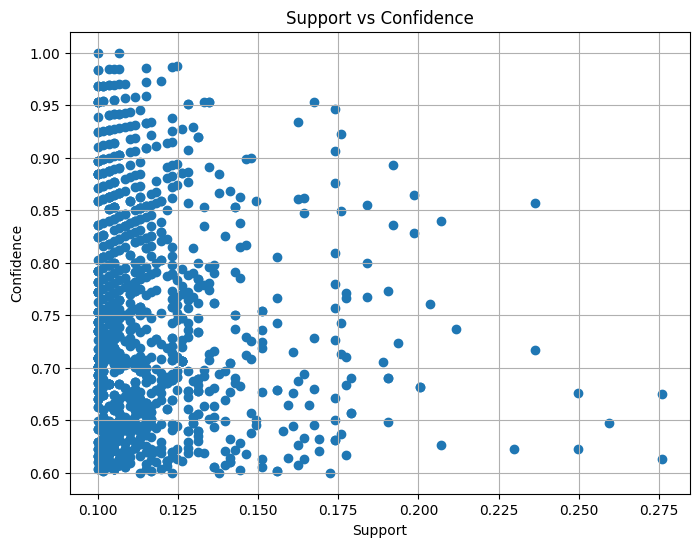

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(rules['support'], rules['confidence'])

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.grid(True)

plt.show()

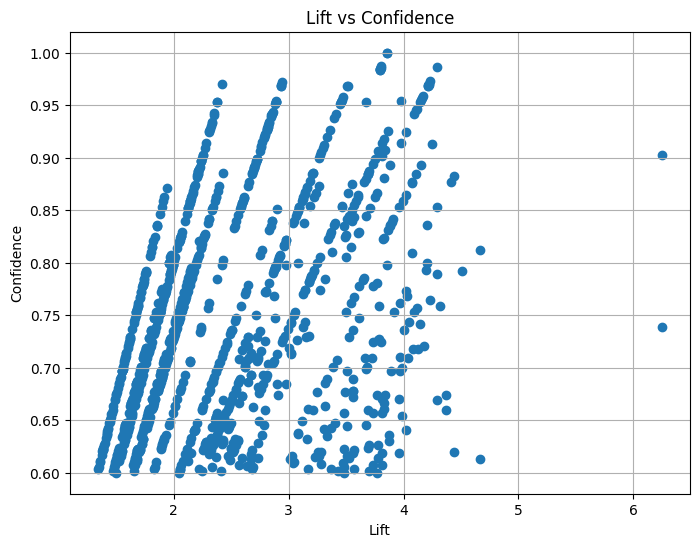

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(rules['lift'], rules['confidence'])

plt.xlabel('Lift')
plt.ylabel('Confidence')
plt.title('Lift vs Confidence')
plt.grid(True)

plt.show()

#### Висновок

У ході роботи було досліджено методи пошуку асоціативних правил на основі даних про вподобання користувачів. Отримані результати показали, що користувачі часто обирають фільми зі схожими характеристиками або з однієї франшизи, а також що алгоритм Apriori ефективно виявляє такі закономірності.